## Análisis de incosistencias/patrones en los datos procesados

**Objetivo: Limpiar los datos**

FALTA POR HACER:
- Diferencia entre llegada_punto y salida_punto (en distancia y en tiempo?)
- Gráficos de tráfico por horas
- Buscar dias - outliers
- Buscar patrones - cada semana/dia por tipo de avion...

#### Carga de Datos

In [1]:
import pandas as pd
import geopandas as gpd

import plotly.express as px
import matplotlib.pyplot as plt
from adjustText import adjust_text # basicamente ayuda a que el texto no solape en el mapa

import folium
from folium.plugins import TimestampedGeoJson
from plotly_calplot import calplot

In [2]:
df_original = pd.read_csv("../../data/Train/train.csv", sep=";")
df_original.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11
1,abfdd1,2025-01-01 12:53:57.851,2025-01-01 12:54:15.692,2025-01-01 12:55:08.113,70.262,Heavy (larger than 136000 kg),-3.572788,40.491846,-3.573818,40.491858,Z3,False,18R/36L,2025-01-01,12
2,4cacdf,2025-01-01 10:20:25.104,2025-01-01 10:20:38.071,2025-01-01 10:21:24.027,58.923,Medium 2 (between 34000 kg to 136000 kg),-3.561172,40.501179,-3.560085,40.501343,Y3,False,18L/36R,2025-01-01,10
3,34754c,2025-01-01 05:37:49.944,2025-01-01 05:38:03.062,2025-01-01 05:38:52.151,62.207,Medium 2 (between 34000 kg to 136000 kg),-3.576462,40.492481,-3.575488,40.492766,Z4,False,18R/36L,2025-01-01,5
4,34754c,2025-01-01 12:45:58.757,2025-01-01 12:46:16.737,2025-01-01 12:48:41.019,162.262,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492475,-3.575519,40.492777,Z4,False,18R/36L,2025-01-01,12


**Filtramos por `parado` = True**

In [3]:
df_original = df_original[df_original.parado]

In [4]:
# Para comparar con preprocesado del csv de 1 semana de diciembre
#mask = (df_original['despegue'] >= '2024-12-01') & (df_original['despegue'] <= '2024-12-08')
#df_original = df_original[mask]

In [5]:
df_original.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue'],
      dtype='object')

### Cuántos despegues y cuándo son

In [6]:
counts = df_original.parado.value_counts().reset_index()
counts.columns = ['parado', 'count']
fig = px.bar(counts, x='parado', y='count', text='count',width=500, height=500)
fig.show()

In [7]:
print('Entre que fechas son los despegues')
print(df_original.despegue.min(), " -- ", df_original.despegue.max())

Entre que fechas son los despegues
2024-11-07 00:27:49.530  --  2025-01-31 23:28:31.552


In [8]:
import warnings

values = pd.to_datetime(df_original.drop_duplicates(subset=['despegue', 'ICAO'])['despegue']).dt.floor('d').value_counts().reset_index()
with warnings.catch_warnings(): # pa evitar warning
        warnings.simplefilter("ignore")
        fig_2024 = calplot(values[values['despegue'].dt.year == 2024], 
                x='despegue', 
                y='count',
                name='count',
                title = '2024',
                dark_theme=True,
                showscale=True,
                colorscale="Viridis",
                start_month=11,
                month_lines_width=3,
                total_height=300
        )

        fig_2025 = calplot(values[values['despegue'].dt.year == 2025], 
                x='despegue', 
                y='count',
                name='count',
                title = '2025',
                dark_theme=True,
                showscale=True,
                colorscale="Viridis",
                end_month=2,
                month_lines_width=3,
                total_height=300,
        )

In [9]:
fig_2024.show()
fig_2025.show()

**Faltan datos de la primera semana de Noviembre y la última semana de Diciembre**

### Análisis tiempo de espera

In [10]:
px.histogram(df_original, 'tiempo_espera', title='Distribución segundos de espera').show()
px.box(df_original, 'tiempo_espera').show()

Vemos cuantos aviones hay que esperan mas de 20 minutos (hemos visto que si bajamos el umbral a 15 minutos, hay bastantes que se descartan).

In [11]:
UMBRAL = 20 * 60
print(df_original[df_original.tiempo_espera >= UMBRAL].holding_point.value_counts())
print("\nTOTAL SUM: ", (df_original.tiempo_espera >= UMBRAL).sum())

holding_point
KA8    18
KA6     8
Z1      5
Y1      5
Y3      4
Z4      3
K1      2
Z3      2
LE      2
Y2      1
Z6      1
K2      1
Name: count, dtype: int64

TOTAL SUM:  52


In [12]:
df_original[df_original.tiempo_espera >= UMBRAL].sort_values(by='tiempo_espera').head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
27479,3c64a7,2024-11-25 11:45:02.453,2024-11-25 11:45:40.590,2024-11-25 12:05:38.691,1236.238,Medium 2 (between 34000 kg to 136000 kg),-3.559784,40.494347,-3.558868,40.494896,K2,True,14L/32R,2024-11-25,12
27343,73806f,2024-11-25 11:44:42.419,2024-11-25 12:05:38.488,2024-11-25 12:05:38.488,1256.069,Medium 2 (between 34000 kg to 136000 kg),-3.560990,40.495594,-3.559982,40.495605,K1,True,14L/32R,2024-11-25,12
28449,4ba9c2,2024-11-27 17:01:05.223,2024-11-27 17:20:51.220,2024-11-27 17:23:39.525,1354.302,Heavy (larger than 136000 kg),-3.561209,40.499423,-3.560085,40.499574,Y1,True,18L/36R,2024-11-27,17
32340,aaa6e4,2024-12-06 16:05:10.232,2024-12-06 16:18:55.878,2024-12-06 16:29:27.024,1456.792,Heavy (larger than 136000 kg),-3.572556,40.490593,-3.573532,40.491005,Z1,True,18R/36L,2024-12-06,16
15184,347309,2025-01-28 14:26:35.426,2025-01-28 14:34:01.177,2025-01-28 14:51:53.764,1518.338,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499462,-3.560054,40.499597,Y1,True,18R/36L,2025-01-28,14


In [13]:
def getCheckURL(icao, timestamp):
    print(f"https://globe.adsbexchange.com/?icao={icao}&showTrace={timestamp}")

getCheckURL("34604e","2024-12-16")

https://globe.adsbexchange.com/?icao=34604e&showTrace=2024-12-16


Los eliminamos, ya que son casos muy puntuales y afectan mucho la distribución

In [14]:
df_clean = df_original[df_original.tiempo_espera < UMBRAL].copy()
print(df_original.shape[0], "->", df_clean.shape[0])

13997 -> 13945


In [15]:
print(f"Nos hemos quedado con el {round(100 * df_clean.shape[0] / df_original.shape[0], 2)} % de los datos")

Nos hemos quedado con el 99.63 % de los datos


In [16]:
px.histogram(df_clean, 'tiempo_espera', title=f'Distribución segundos de espera (filter < {UMBRAL} segundos)').show()
px.box(df_clean, 'tiempo_espera').show()

### Análisis de NA's

In [17]:
df_clean.isna().sum()

ICAO               0
llegada_punto      0
salida_punto      23
despegue           0
tiempo_espera      0
aircraft_type     51
llegada_lon        0
llegada_lat        0
salida_lon        23
salida_lat        23
holding_point      0
parado             0
runway             3
fecha_despegue     0
hora_despegue      0
dtype: int64

In [18]:
df_clean[df_clean['aircraft_type'].isna()].head(3)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
406,393322,2025-01-01 05:33:52.792,2025-01-01 05:34:59.324,2025-01-01 05:36:55.216,182.424,NaN,-3.576253,40.491521,-3.575363,40.492067,Z2,True,18R/36L,2025-01-01,5
479,34604b,2025-01-01 07:20:27.290,2025-01-01 07:21:33.170,2025-01-01 07:23:00.125,152.835,NaN,-3.560897,40.501180,-3.560101,40.501331,Y3,True,18L/36R,2025-01-01,7
820,34530e,2025-01-02 12:19:48.855,2025-01-02 12:24:30.672,2025-01-02 12:26:16.481,387.626,NaN,-3.576080,40.492550,-3.575485,40.492790,Z4,True,18R/36L,2025-01-02,12


Error en los datos: 2 despegues en menos de 5 minutos!!!

In [19]:
getCheckURL("34604b","2025-01-01")

https://globe.adsbexchange.com/?icao=34604b&showTrace=2025-01-01


In [20]:
df_clean[df_clean['ICAO'] == '34604b'].sort_values(by='despegue', ascending=True).iloc[37:39]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
478,34604b,2025-01-01 07:16:56.732,2025-01-01 07:20:24.804,2025-01-01 07:20:24.804,208.072,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.50118,-3.560898,40.501179,Y3,True,18L/36R,2025-01-01,7
479,34604b,2025-01-01 07:20:27.290,2025-01-01 07:21:33.170,2025-01-01 07:23:00.125,152.835,NaN,-3.560897,40.50118,-3.560101,40.501331,Y3,True,18L/36R,2025-01-01,7


In [21]:
df_clean[df_clean['runway'].isna()]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
32450,34530e,2024-12-06 10:37:17.504,2024-12-06 10:37:37.380,2024-12-06 10:37:37.380,19.876,Medium 2 (between 34000 kg to 136000 kg),-3.572861,40.491840,-3.573471,40.491829,Z3,True,NaN,2024-12-06,10
37965,3452c8,2024-12-15 07:04:08.506,2024-12-15 07:07:59.705,2024-12-15 07:07:59.705,231.199,Medium 2 (between 34000 kg to 136000 kg),-3.576159,40.491683,-3.575790,40.491898,Z2,True,NaN,2024-12-15,7
41586,345698,2024-12-22 10:38:32.202,2024-12-22 10:41:27.946,2024-12-22 10:41:27.946,175.744,Medium 2 (between 34000 kg to 136000 kg),-3.572693,40.491840,-3.572866,40.491835,Z3,True,NaN,2024-12-22,10


In [22]:
getCheckURL("34530e","2024-12-06")

https://globe.adsbexchange.com/?icao=34530e&showTrace=2024-12-06


In [23]:
df_clean[df_clean['salida_punto'].isna()].head(2)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
2470,345686,2025-01-05 15:58:17.141,NaN,2025-01-05 16:03:38.818,321.677,Medium 2 (between 34000 kg to 136000 kg),-3.574864,40.486900,NaN,NaN,LD,True,14R/32L,2025-01-05,16
2501,3ce005,2025-01-05 16:34:05.478,NaN,2025-01-05 16:45:47.981,702.503,Medium 1 (between 7000 kg and 34000 kg),-3.574723,40.486795,NaN,NaN,LD,True,14R/32L,2025-01-05,16


Eliminamos filas con algún NA

In [24]:
df_clean = df_clean.dropna()

### Numero de despegues por avion

In [25]:
icao_counts = df_clean.drop_duplicates(subset=['ICAO', 'despegue']) # para no contar el mismo despegue 2 veces si pasa por 2 puntos
icao_counts = icao_counts.groupby(["ICAO", "aircraft_type"])["despegue"].count()
print("MAX", icao_counts.max())
print("MEDIA", icao_counts.mean())
print("MEDIANA", icao_counts.median())
fig = px.histogram(icao_counts.reset_index(), 'despegue', title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

MAX 92
MEDIA 5.945540308747856
MEDIANA 2.0


In [26]:
fig = px.histogram(icao_counts.reset_index(), 'despegue', color="aircraft_type", title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [27]:
hp_count = df_clean.groupby(["ICAO", "despegue"])["holding_point"].count().sort_values(ascending=False)

In [28]:
hp_count[hp_count > 1]

ICAO    despegue               
4bb276  2025-01-27 11:51:23.637    2
3475d3  2025-01-07 15:27:01.265    2
345103  2024-11-09 14:45:11.033    2
Name: holding_point, dtype: int64

In [29]:
df_clean[df_clean.ICAO == '4ca804'].sort_values(by=['despegue', 'llegada_punto']).iloc[8:]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
22009,4ca804,2024-11-15 16:46:49.392,2024-11-15 16:47:52.751,2024-11-15 16:49:12.126,142.734,Medium 2 (between 34000 kg to 136000 kg),-3.559789,40.494337,-3.558868,40.494896,K2,True,14L/32R,2024-11-15,16
2608,4ca804,2025-01-05 05:03:16.097,2025-01-05 05:05:01.154,2025-01-05 05:07:39.205,263.108,Medium 2 (between 34000 kg to 136000 kg),-3.576584,40.492458,-3.575504,40.492766,Z4,True,18R/36L,2025-01-05,5
2609,4ca804,2025-01-05 13:57:14.563,2025-01-05 13:58:57.501,2025-01-05 14:00:25.095,190.532,Medium 2 (between 34000 kg to 136000 kg),-3.559789,40.494349,-3.558868,40.494884,K2,True,14L/32R,2025-01-05,14
3209,4ca804,2025-01-06 07:02:02.684,2025-01-06 07:03:44.509,2025-01-06 07:05:39.889,217.205,Medium 2 (between 34000 kg to 136000 kg),-3.578125,40.484802,-3.576996,40.484711,LB,True,14R/32L,2025-01-06,7


#### Solo hay 2 casos donde los aviones pasan por mas de 1 punto de espera al despegar

In [30]:
gdf = gpd.read_file('../../data/geojson/holding_points.geojson')
taxiways = gpd.read_file("../../data/geojson/taxiways.geojson")
runways = gpd.read_file("../../data/geojson/runways.geojson")
gdf.head(1)

,OBJECTID,LASTMOD_DATE,LAT_TXT,LONG_TXT,GFID,LATLONG_RESOLUTION,LATLONG_ACCURACY,LASTMOD_AMDT,DESIGNATOR,STOPBAR,PARENT_ADHP,REMARKS_TXT,geometry
0,1190,1689239365000,"402926,3514N","0033423,1352W",87F4653B-2759-449F-8558-223A85EE69EA,None,None,AIRAC - 10/23,Z1,1.0,C46939D7-07D9-4BA7-9D4C-AF3E1B30DCD0,Con iluminación LED. // LED ligthing.,POINT (-3.57309 40.49065)


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/3208627513.py:9: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/3208627513.py:12: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/3208627513.py:27: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



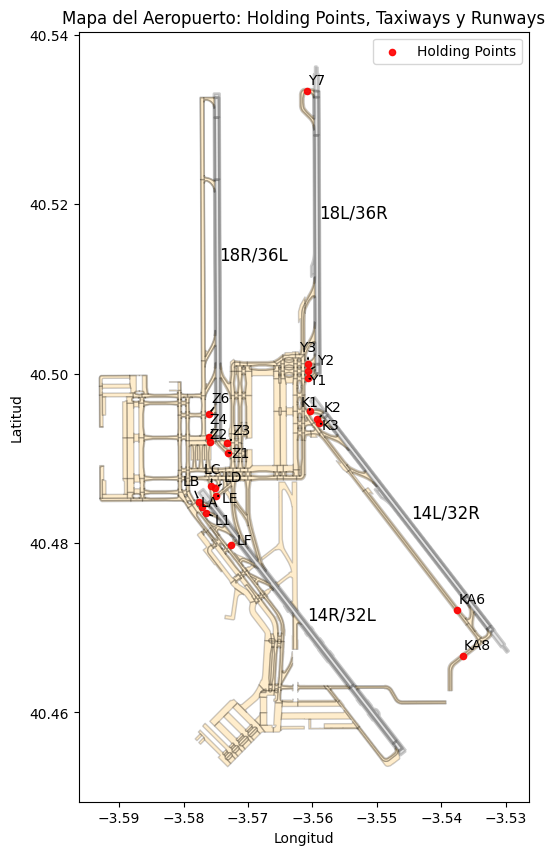

In [31]:


fig, ax = plt.subplots(figsize=(10, 10))

texts = []
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['DESIGNATOR']):
    texts.append(ax.text(x, y, label, fontsize=10, ha='left', va='bottom'))

# convertimos en una sola pieza (poligono)
runways_grouped = runways.dissolve(by='RWY', as_index=False)
runways_grouped['centroid'] = runways_grouped.geometry.centroid
runways_grouped.head()

for x, y, label in zip(runways_grouped.centroid.x, runways_grouped.centroid.y, runways_grouped['RWY']):
    texts.append(ax.text(x, y, label, fontsize=12, ha='left', va='bottom'))

# Plot layers
runways.plot(ax=ax, color="gray", edgecolor="black", alpha=0.2, linewidth=2, label="Runways")
taxiways.plot(ax=ax, color="orange", edgecolor="black", alpha=0.2, label="Taxiways")
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.9, label="Holding Points")

# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# Añadir título y leyenda
plt.title("Mapa del Aeropuerto: Holding Points, Taxiways y Runways")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

# Mostrar el mapa
plt.show()

In [32]:
setAll = set(gdf.DESIGNATOR.unique())
setData = set(df_clean.holding_point.unique())
diff = setAll.difference(setData)
if (bool(diff)):
    print("Puntos de espera que NO estan en los DATOS PROCESADOS:")
    print(diff)
else:
    print("TODOS LOS PUNTOS DE ESPERA ESTAN EN LOS DATOS")

Puntos de espera que NO estan en los DATOS PROCESADOS:
{'KA6', 'LD', 'KA8', 'Y7', 'LF'}


Vemos la distribución de las pistas

In [33]:
# para no contar 2 veces la misma pista cuando pasa por 2 puntos antes de despegar
counts = df_clean.drop_duplicates(subset=['runway', 'despegue', 'ICAO'])['runway'].value_counts().reset_index()
counts.columns = ['runway', 'count']
fig = px.bar(counts, x='runway', y='count', text='count',width=500, height=500)
fig.show()

In [34]:
value_counts = df_clean['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

fig = px.bar(value_counts, x='holding_point', y='count', title='Despegues por puntos de espera', text='count')

fig.update_layout(template='plotly_white')

fig.show()


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/995842764.py:13: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/995842764.py:16: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/995842764.py:31: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



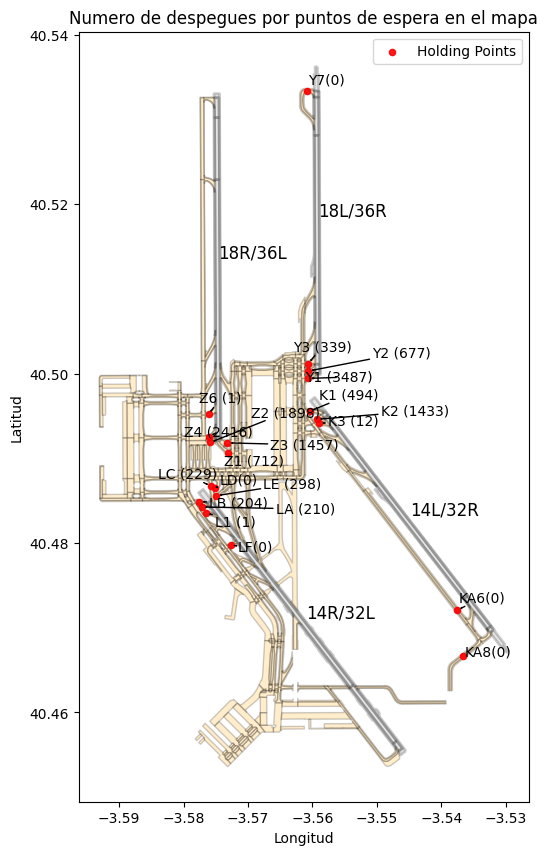

In [35]:
fig, ax = plt.subplots(figsize=(10, 10))

texts = []
value_counts = df_clean['holding_point'].value_counts()
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['DESIGNATOR']):
    label_with_count = label + "(0)"
    if label in value_counts:
        label_with_count = f"{label} ({value_counts[label]})"
    texts.append(ax.text(x, y, label_with_count, fontsize=10, ha='left', va='bottom'))

# convertimos en una sola pieza (poligono)
runways_grouped = runways.dissolve(by='RWY', as_index=False)
runways_grouped['centroid'] = runways_grouped.geometry.centroid
runways_grouped.head()

for x, y, label in zip(runways_grouped.centroid.x, runways_grouped.centroid.y, runways_grouped['RWY']):
    texts.append(ax.text(x, y, label, fontsize=12, ha='left', va='bottom'))

# Plot layers
runways.plot(ax=ax, color="gray", edgecolor="black", alpha=0.2, linewidth=2, label="Runways")
taxiways.plot(ax=ax, color="orange", edgecolor="black", alpha=0.2, label="Taxiways")
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.9, label="Holding Points")

# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# Añadir título y leyenda
plt.title("Numero de despegues por puntos de espera en el mapa")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

# Mostrar el mapa
plt.show();

Meter un color más rojo o más verde dependiendo de si tiene mas o menos despegues (se puede hacer una versión animada??)

In [36]:
counts_fecha = df_clean[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

df_folium = counts_fecha.value_counts().reset_index()
df_folium = df_folium.merge(gdf[['DESIGNATOR', 'geometry']], left_on='holding_point', right_on='DESIGNATOR', how='left')
df_folium = df_folium.dropna(subset=['geometry'])  # Remove rows without geometry

# Convert to GeoDataFrame
gdf_anim = gpd.GeoDataFrame(df_folium, geometry='geometry')
gdf_anim.crs = gdf.crs  # inherit CRS

# STEP 2: Build GeoJSON format for Folium TimestampedGeoJson

# Folium expects a GeoJSON structure with timestamps
# We create a FeatureCollection with 'time' and 'iconstyle' properties

def gdf_to_timestamped_geojson(gdf):
    features = []
    for _, row in gdf.iterrows():
        feature = {
            'type': 'Feature',
            'geometry': row.geometry.__geo_interface__,
            'properties': {
                'time': row['despegue'].isoformat(),
                'popup': f"Holding Point: {row['holding_point']} count: {row['count']}",
                'icon': 'circle',
                'iconstyle': {
                    'fillColor': 'red',
                    'fillOpacity': 0.8,
                    'stroke': True,
                    'radius': 6
                }
            }
        }
        features.append(feature)

    return {
        'type': 'FeatureCollection',
        'features': features
    }

geojson_data = gdf_to_timestamped_geojson(gdf_anim)

# STEP 3: Create the Folium map

# Center of the map
map_center = [gdf.geometry.y.mean(), gdf.geometry.x.mean()]

m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

TimestampedGeoJson(
    data=geojson_data,
    transition_time=500,
    period='PT1H',  # ISO 8601 duration: 1 hour
    add_last_point=True,
    auto_play=True,
    loop=False,
    #max_speed=1,
    loop_button=True,
    date_options='YYYY-MM-DD HH:mm',
    time_slider_drag_update=True
).add_to(m)


m

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/1328130319.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [37]:
# Extract latitude and longitude from geometry
gdf['lat'] = gdf.geometry.y
gdf['lon'] = gdf.geometry.x

# Value counts
value_counts = df_clean['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

# Merge counts into GeoDataFrame
gdf_merged = gdf.merge(value_counts, left_on='DESIGNATOR', right_on='holding_point', how='left')
gdf_merged['count'] = gdf_merged['count'].fillna(0)

# Plot the holding points on a map
fig = px.scatter_mapbox(
    gdf_merged,
    lat='lat',
    lon='lon',
    text='DESIGNATOR',
    size='count',
    size_max=20,
    zoom=11.4
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

fig.show();

In [38]:
counts_fecha = df_clean[['despegue', 'runway']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['runway'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'runway'])
counts_full = counts_fecha.set_index(['despegue', 'runway']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='runway',
              title='Despegues por horas y pista')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/3979434919.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/3979434919.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, 

In [39]:
counts_fecha = df_clean[['despegue', 'runway']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['runway'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'runway'])
counts_full = counts_fecha.set_index(['despegue', 'runway']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='runway',
              title='Despegues por horas y pista (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2151714037.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2151714037.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, 

In [40]:
counts_fecha = df_clean[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['holding_point'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'holding_point'])
counts_full = counts_fecha.set_index(['despegue', 'holding_point']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='holding_point',
              title='Despegues por horas y holding point')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/681791611.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/681791611.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, ca

In [41]:
counts_fecha = df_clean[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['holding_point'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'holding_point'])
counts_full = counts_fecha.set_index(['despegue', 'holding_point']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='holding_point',
              title='Despegues por horas y holding point (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2661020277.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2661020277.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, 

In [42]:
counts_fecha = df_clean[['despegue', 'aircraft_type']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['aircraft_type'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'aircraft_type'])
counts_full = counts_fecha.set_index(['despegue', 'aircraft_type']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='aircraft_type',
              title='Despegues por horas y tipo de avion')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/4145516821.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/4145516821.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, 

In [43]:
counts_fecha = df_clean[['despegue', 'aircraft_type']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['aircraft_type'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'aircraft_type'])
counts_full = counts_fecha.set_index(['despegue', 'aircraft_type']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='aircraft_type',
              title='Despegues por horas y tipo de avion (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2502706293.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_15272/2502706293.py:8: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/Users/tyomikjan/UNIVERSITY/PD2/1090_riddle/.venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, 

In [44]:
pivot_df = df_clean.pivot_table(index='holding_point', columns='runway', values='despegue', aggfunc='count').T

fig = px.imshow(pivot_df, title='Despegues por pista y punto de espera')
fig.show()


In [45]:
pivot_df = df_clean.pivot_table(index='holding_point', columns='aircraft_type', values='despegue', aggfunc='count').T

fig = px.imshow(pivot_df, title='Puntos de espera por los que pasan diferentes tipos de aviones')
fig.show()